# Proyek Akhir: Membuat Model Sistem Rekomendasi
- Nama  : Alya Fauzia Azizah
- Email : alyafauziaaz25@gmail.com

## 1. Import Package

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score
from zipfile import ZipFile
import tensorflow as tf
from tensorflow.keras import layers
from pathlib import Path
import re

!pip install kagglehub
import kagglehub

## 2. Loading Data

In [ ]:
# Download latest version
path = kagglehub.dataset_download("arashnic/book-recommendation-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/book-recommendation-dataset


In [ ]:
books_path = os.path.join(path, 'Books.csv')
ratings_path = os.path.join(path, 'Ratings.csv')
users = os.path.join(path, 'Users.csv')

books = pd.read_csv(books_path, encoding='utf-8')
ratings = pd.read_csv(ratings_path, encoding='utf-8')
users = pd.read_csv(users, encoding='utf-8')

print('Shape pada file Books', books.shape)
print('Shape pada file Ratings', ratings.shape)
print('Shape pada file Users', users.shape)

<ipython-input-3-2609474425>:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv(books_path, encoding='utf-8')


Shape pada file Books (271360, 8)
Shape pada file Ratings (1149780, 3)
Shape pada file Users (278858, 3)


In [ ]:
print('Dataset Books.csv')
books.head()

Dataset Books.csv


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [ ]:
print('Dataset Ratings.csv')
ratings.head()

Dataset Ratings.csv


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [ ]:
print('Dataset Users.csv')
users.head()

Dataset Users.csv


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [ ]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


In [ ]:
print('Jumlah buku pada data: ', len(books['ISBN'].unique()))
print('Total buku yang diberi rating dari pembaca: ', len(ratings['ISBN'].unique()))
print('Jumlah data pengguna: ', len(users['User-ID'].unique()))

Jumlah buku pada data:  271360
Total buku yang diberi rating dari pembaca:  340556
Jumlah data pengguna:  278858


Dapat diketahui bahwa:

1. Variabel `Books` memiliki jumlah data 271.360 data dengan 8 kolom, yaitu:
  - `ISBN`, nomor identifikasi buku unik yang diberikan oleh Badan ISBN Internasional.
  - `Book-Title`, judul buku.
  - `Book-Author`, Penulis buku.
  - `Year-Of-Publication`, Tahun buku diterbitkan.
  - `Publisher`, Penerbit buku.
  - `Image-URL-S`, diperoleh dari web Amazon Web Service (AWS) untuk menautkan ke gambar sampul kecil.
  - `Image-URL-M`, diperoleh dari web AWS untuk menautkan ke gambar sampul sedang.
  - `Image-URL-L`, diperoleh dari web AWS untuk menautkan ke gambar sampul besar.
2. Dataset `Ratings`, memiliki jumlah data 340.556 data dengan 3 kolom, yaitu:
  - `User-ID`, ID pengguna yang dianonimus dan petakan dengan nilai integer.
  - `ISBN`, nomor identifikasi buku yang diberikan rating oleh users.
  - `Book-Rating`, rating buku bernilai 0 sampai 10 (semakin tinggi nilai, semakin besar apresiasi).
3. Dataset `Users`, memiliki jumlah data 278.858 data dengan 3 kolom, yaitu:
  - `User-ID`, ID pengguna yang dianonimuskan dan dipetakan dengan nilai integer yang memberikan informasi pada data user.
  - `Location`, data demografi lokasi user jika diizinkan oleh pengguna.
  - `Age`, data demografi berupa umur pengguna jika diizinkan oleh pengguna.

## 3. Univariate Data Analysis
### Variabel Books

In [ ]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


Fitur `Year-Of-Publication` merupakan tahun dan mengalami error ketika akan mengubah tipe data menjadi integer. Ternyata hasil dari publisher DK-Publishing Inc melakukan kesalahan input. Maka pada tahap data data preparation, baris DK-Publishing akan dihapus. Variabel `Image-URL-S`, `Image-URL-M`, dan `Image-URL-L` tidak akan digunakan untuk proses pembangunan model, sehingga hanya akan memiliki 5 fitur saja.

In [ ]:
books = books.drop(['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], axis=1)
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company


In [ ]:
print('Nilai unik pada ISBN:', len(books['ISBN'].unique()))
print('Nilai unik pada Book-Title:', len(books['Book-Title'].unique()))
print('Nilai unik pada Book-Author:', len(books['Book-Author'].unique()))
print('Nilai unik pada Year-Of-Publication:', len(books['Year-Of-Publication'].unique()))
print('Nilai unik pada Publisher:', len(books['Publisher'].unique()))

Nilai unik pada ISBN: 271360
Nilai unik pada Book-Title: 242135
Nilai unik pada Book-Author: 102023
Nilai unik pada Year-Of-Publication: 202
Nilai unik pada Publisher: 16808


In [ ]:
books[(books['Year-Of-Publication'] == 'DK Publishing Inc') | (books['Year-Of-Publication'] == 'Gallimard')]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...


Mendeteksi nilai invalid karena salah input antara `Book-Author` dengan `Year-Of-Publication`

Data pada variabel `ISBN` sebanyak 271.360 sedangkan pada variabel `Book-Title` memiliki data sebanyak 242.135. Hal ini mengindikasi bahwa setiap buku harus memiliki nilai ISBN yang unik masing-masing. Dalam kasus ini, dataset akan disaring untuk memastikan bahwa setiap buku memiliki ISBN masing-masing.

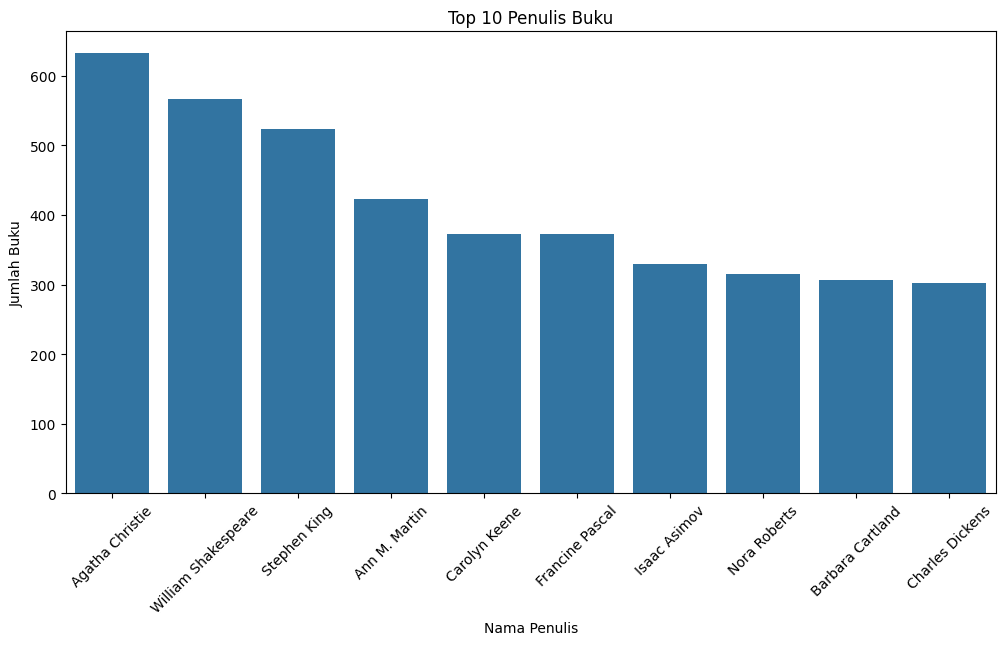

In [ ]:
top_10_authors = books['Book-Author'].value_counts().head(10)

def barplot_visualization(data, x_label, y_label, title):
  plt.figure(figsize=(12, 6))
  sns.barplot(x=data.index, y=data.values)
  plt.xticks(rotation=45)
  plt.xlabel(x_label)
  plt.ylabel(y_label)
  plt.title(title)
  plt.show()

x_author = 'Nama Penulis'
y_author = 'Jumlah Buku'
title_author = 'Top 10 Penulis Buku'
barplot_visualization(top_10_authors, x_author, y_author, title_author)

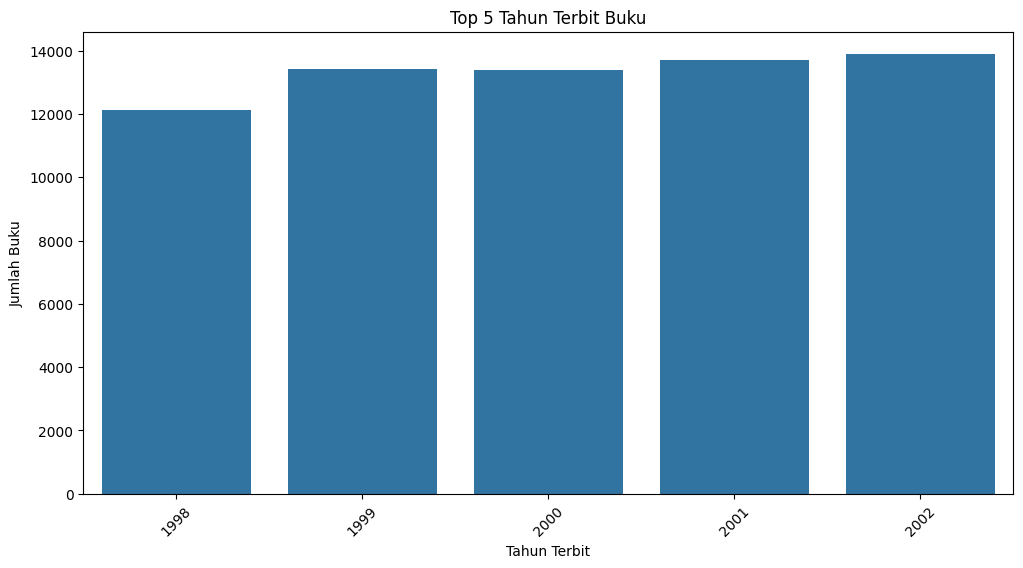

In [ ]:
top_5_year = books['Year-Of-Publication'].value_counts().head(5)

x_year = 'Tahun Terbit'
y_year = 'Jumlah Buku'
title_year = 'Top 5 Tahun Terbit Buku'
barplot_visualization(top_5_year, x_year, y_year, title_year)

Dari visualisasi di atas, diketahui bahwa penulis terbanyak menerbitkan buku adalah Agatha Cristie, dengan menerbitkan lebih dari 600 buku. sedangkan tahun paling banyak menerbitkan buku pada tahun 2002.

### Variabel Rating

In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [ ]:
print('Nilai unik pada ISBN:', len(ratings['ISBN'].unique()))
print('Nilai unik pada User-ID:', len(ratings['User-ID'].unique()))
print('Nilai unik pada Book-Rating:', len(ratings['Book-Rating'].unique()))

Nilai unik pada ISBN: 340556
Nilai unik pada User-ID: 105283
Nilai unik pada Book-Rating: 11


Dari informasi di atas, diketahui 105,283 pengguna telah memberikan rating kepada buku, jumlah buku yang diberikan rating sebanyak 34.556, dan rating yang diberikan berkisar 0 sampai 11.

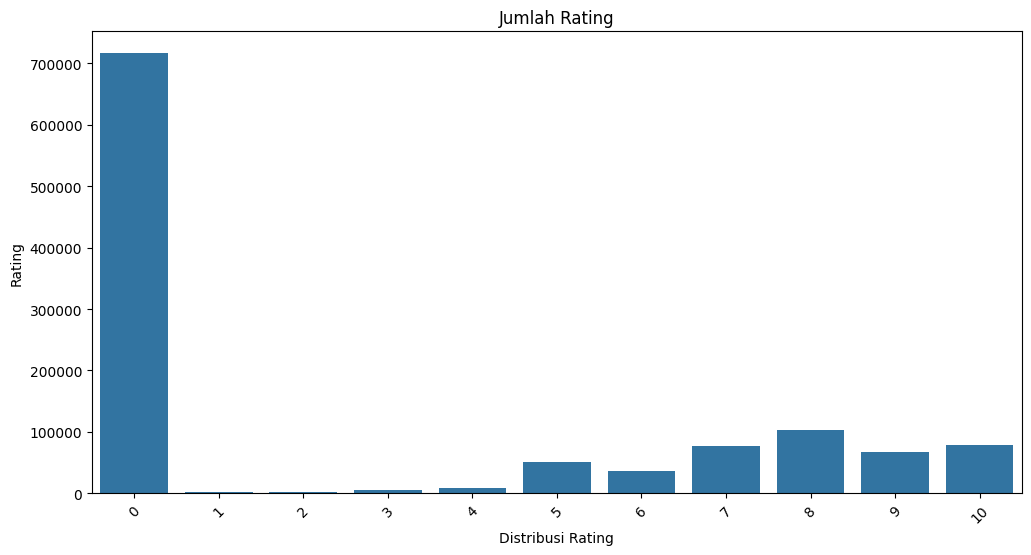

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=ratings, x='Book-Rating')
plt.xticks(rotation=45)
plt.xlabel('Distribusi Rating')
plt.ylabel('Rating')
plt.title('Jumlah Rating')
plt.show()

Dari visualisasi di atas, sebagian besar pengguna memberikan rating 0 atau tidak diberikan rating oleh pengguna. Selain itu, rating paling banyak diberikan dengan nilai 8, 7, dan 10.

### Variable Users

In [ ]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


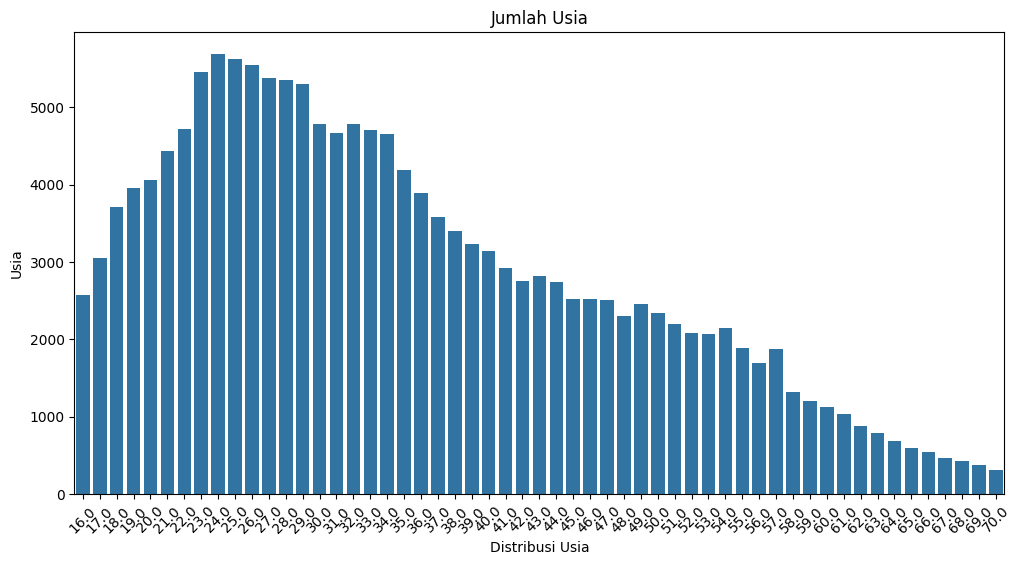

In [ ]:
users_filter = users[(users['Age']>=16) & (users['Age']<=70)]

plt.figure(figsize=(12, 6))
sns.countplot(data=users_filter, x='Age')
plt.xticks(rotation=45)
plt.xlabel('Distribusi Usia')
plt.ylabel('Usia')
plt.title('Jumlah Usia')
plt.show()

Interpretasi:
1. Terdapat data yang kosong pada fitur `Age`.
2. Distribusi data miring ke sebelah kanan (right-skewd).
3. Pengguna yang memberikan rating terbanyak berada di rentang usia 20 hingga awal 30 tahunan.

Data pada fitur ini nantinya hanya memakai dataset `books` dan `ratings`.

## 5. Data Preprocessing

### Membuat nilai modus berdasarkan ISBN

Membuat variabel untuk menentukan nilai rating pada buku berdasarkan ISBN. Menggunakan nilai modus, karena ISBN merupakan data ordinal yang tidak bisa diwakilkan dengan rata-rata.

In [ ]:
rat_mod = ratings.groupby('ISBN')['Book-Rating'].agg(lambda x: x.mode().iloc[0])
rat_mod

,Book-Rating
ISBN,
0330299891,0
0375404120,0
0586045007,0
9022906116,0
9032803328,0
...,...
cn113107,0
ooo7156103,7
§423350229,0


### Merge Data Buku dengan Data Rating

Penyatuan data dilakukan berdasarkan ISBN pada fitur `rat_mod` sebelumnya.

In [ ]:
books_rating = pd.merge(books[['ISBN', 'Book-Title', 'Book-Author','Publisher', 'Year-Of-Publication']],
                        rat_mod, # Add the ratings DataFrame here
                        on='ISBN', how='left')
books_rating

,ISBN,Book-Title,Book-Author,Publisher,Year-Of-Publication,Book-Rating
0,0195153448,Classical Mythology,Mark P. O. Morford,Oxford University Press,2002,0.0
1,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,2001,0.0
2,0060973129,Decision in Normandy,Carlo D'Este,HarperPerennial,1991,0.0
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,Farrar Straus Giroux,1999,0.0
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,W. W. Norton &amp; Company,1999,0.0
...,...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,Random House Childrens Pub (Mm),1988,7.0
271356,0525447644,From One to One Hundred,Teri Sloat,Dutton Books,1991,4.0
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,HarperSanFrancisco,2004,0.0
271358,0192126040,Republic (World's Classics),Plato,Oxford University Press,1996,0.0


## 5. Data Preparation Pendekatan Content-Based Filtering

### Menangani missing value

In [ ]:
books_rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ISBN                 271360 non-null  object 
 1   Book-Title           271360 non-null  object 
 2   Book-Author          271358 non-null  object 
 3   Publisher            271358 non-null  object 
 4   Year-Of-Publication  271360 non-null  object 
 5   Book-Rating          270151 non-null  float64
dtypes: float64(1), object(5)
memory usage: 12.4+ MB


Data yang kosong berasal dari fitur `Book-Author`, `Publisher`, dan `Book-Rating`. Penanganan yang dilakukan dengan cara menghapus baris yang kosong.

In [ ]:
books_rating = books_rating.dropna()

### Menghapus Nilai Invalid

Menghapus baris invalid, meliputi:
Salah input pada fitur `Year-Of-Publication` yang memiliki nilai "DK Publishing INC" dan "Gallimard".

In [ ]:
# Menghapus nilai salah input dengan nilai "DK Publishing INC" dan "Gallimard".
temp = books_rating[(books_rating['Year-Of-Publication'] == 'DK Publishing Inc') | (books_rating['Year-Of-Publication'] == 'Gallimard')]
books_rating = books_rating.drop(temp.index)
books_rating[(books_rating['Year-Of-Publication'] == 'DK Publishing Inc') | (books_rating['Year-Of-Publication'] == 'Gallimard')]

,ISBN,Book-Title,Book-Author,Publisher,Year-Of-Publication,Book-Rating


In [ ]:
books_rating['Year-Of-Publication'].astype('int64')
print(books_rating.dtypes)

ISBN                    object
Book-Title              object
Book-Author             object
Publisher               object
Year-Of-Publication     object
Book-Rating            float64
dtype: object


### Standarisasi ISBN

ISBN merupakan nilai unik yang terdapat pada setiap judul buku. Jika terdapat ISBN dengan nilai yang sama pada dua buku atau lebih, bisa dikatakan bias atau nilai yang tidak valid. Biasanya jumlah huruf pada ISBN adalah 10 hingga 13.

In [ ]:
clean_data = books_rating.sort_values(by='ISBN')
clean_data

,ISBN,Book-Title,Book-Author,Publisher,Year-Of-Publication,Book-Rating
254249,0000913154,The Way Things Work: An Illustrated Encycloped...,C. van Amerongen (translator),Simon &amp; Schuster,1967,8.0
215806,0001010565,Mog's Christmas,Judith Kerr,Collins,1992,0.0
42562,0001046438,Liar,Stephen Fry,Harpercollins Uk,0,9.0
112555,0001046713,Twopence to Cross the Mersey,Helen Forrester,HarperCollins Publishers,1992,0.0
42604,000104687X,"T.S. Eliot Reading \The Wasteland\"" and Other ...",T.S. Eliot,HarperCollins Publishers,1993,6.0
...,...,...,...,...,...,...
72805,B000234N76,Falling Angels,Tracy Chevalier,E P Dutton,2001,0.0
193529,B000234NC6,It Must've Been Something I Ate: The Return of...,Jeffrey Steingarten,Knopf,2002,0.0
131087,B00029DGGO,"Good Wife Strikes Back, The",Elizabeth Buchan,Viking Adult,0,0.0
179424,B0002JV9PY,The Blockade Runners,Jules Verne,Digireads.com,0,0.0


In [ ]:
print('Nilai unik pada ISBN', clean_data['ISBN'].nunique())
print('Nilai unik pada Book-Title', clean_data['Book-Title'].nunique())

Nilai unik pada ISBN 270144
Nilai unik pada Book-Title 241065


Nilai ISBN dan Book-Title tidak sama, dapat dipastikan bahwa terdapat nilai ISBN yang berbeda pada suatu buku.

In [ ]:
import re

def clean_isbn(isbn):
  if pd.isnull(isbn):
    return None
  # Mengambil nilai ISBN dengan panjang 10 hingga 13
  match = re.match(r'^(\d+)', str(isbn))
  if match:
    cleaned = match.group(1)
    if len(cleaned) == 10 or len(cleaned) == 13: # Mengambil ISBN dengan panjang 10 hingga 13
      return cleaned
  return None

clean_data['ISBN_clean'] = clean_data['ISBN'].apply(clean_isbn)
clean_data = clean_data[clean_data['ISBN_clean'].notnull()]

Mengubah data tabular menjadi data list menggunakan fungsi tolist().

In [ ]:
isbn_id = clean_data['ISBN_clean'].tolist()
book_title_id = clean_data['Book-Title'].tolist()
book_author_id = clean_data['Book-Author'].tolist()
publisher_id = clean_data['Publisher'].tolist()
year_id = clean_data['Year-Of-Publication'].tolist()
rating_id = clean_data['Book-Rating'].tolist()

print('Banyaknya nilai ISBN: ',len(isbn_id))
print('Banyaknya nilai Book-Title: ',len(book_title_id))
print('Banyaknya nilai Book-Author: ',len(book_author_id))
print('Banyaknya nilai Publisher: ',len(publisher_id))
print('Banyaknya nilai Year: ',len(year_id))
# print('Banyaknya nilai Rating: ',len(rating_id))

Banyaknya nilai ISBN:  247936
Banyaknya nilai Book-Title:  247936
Banyaknya nilai Book-Author:  247936
Banyaknya nilai Publisher:  247936
Banyaknya nilai Year:  247936


Berdasarkan output di atas, semua fitur memiliki nilai yang sama atau nilai unik. Dataset sekarang berjumlah 247.936 baris data. Langkah selanjutnya adalah membuat kamus untuk memberikan informasi ISBN sebagai key-value dengan Book-Title, Book-Author, Publisher, Year, dan Rating untuk mengembangkan konten sistem rekomendasi.

In [ ]:
books_new = pd.DataFrame(
    {'ISBN': isbn_id,
     'Book-Title': book_title_id,
     'Book-Author': book_author_id,
     'Publisher': publisher_id,
     'Year-Of-Publication': year_id}
)

books_new

,ISBN,Book-Title,Book-Author,Publisher,Year-Of-Publication
0,0000913154,The Way Things Work: An Illustrated Encycloped...,C. van Amerongen (translator),Simon &amp; Schuster,1967
1,0001010565,Mog's Christmas,Judith Kerr,Collins,1992
2,0001046438,Liar,Stephen Fry,Harpercollins Uk,0
3,0001046713,Twopence to Cross the Mersey,Helen Forrester,HarperCollins Publishers,1992
4,0001046934,The Prime of Miss Jean Brodie,Muriel Spark,Trafalgar Square Publishing,1999
...,...,...,...,...,...
247931,9999669972,Being Bullied (Lets Talk About Series),Joy Berry,Smithmark Pub,1989
247932,9999980538,Murphy's Law,Colin Bateman,Headline,2002
247933,9999984584,Anointed,Zev Halevi,Routledge,1987
247934,9999991556,Impact of New Product Introductions on the Mar...,Paul K. Chaney,Marketing Science Inst,1989


Data yang digunakan sangat besar, untuk memanfaatkan komputasi, hanya akan digunakan 20.000 baris data yang akan digunakan.

In [ ]:
# Data Rapih yang akan dijadikan acuan
books_new = books_new[:20000]
books_new

,ISBN,Book-Title,Book-Author,Publisher,Year-Of-Publication
0,0000913154,The Way Things Work: An Illustrated Encycloped...,C. van Amerongen (translator),Simon &amp; Schuster,1967
1,0001010565,Mog's Christmas,Judith Kerr,Collins,1992
2,0001046438,Liar,Stephen Fry,Harpercollins Uk,0
3,0001046713,Twopence to Cross the Mersey,Helen Forrester,HarperCollins Publishers,1992
4,0001046934,The Prime of Miss Jean Brodie,Muriel Spark,Trafalgar Square Publishing,1999
...,...,...,...,...,...
19995,0151027072,Above Suspicion,Helen MacInnes,Harcourt,1989
19996,0151032661,Across the Street,Georges Simenon,Harcourt,1992
19997,0151039674,Agent in Place,Helen MacInnes,Harcourt,1976
19998,0151039682,Voice Of Reason: Hanan Ashrawi and Peace in th...,Barbara Victor,Harcourt,1994


In [ ]:
# Data yang digunakan menggunakan data books_new
df_cbf = books_new.copy()
df_cbf.head()

,ISBN,Book-Title,Book-Author,Publisher,Year-Of-Publication
0,0000913154,The Way Things Work: An Illustrated Encycloped...,C. van Amerongen (translator),Simon &amp; Schuster,1967
1,0001010565,Mog's Christmas,Judith Kerr,Collins,1992
2,0001046438,Liar,Stephen Fry,Harpercollins Uk,0
3,0001046713,Twopence to Cross the Mersey,Helen Forrester,HarperCollins Publishers,1992
4,0001046934,The Prime of Miss Jean Brodie,Muriel Spark,Trafalgar Square Publishing,1999


### TF-IDF Vectorizer

TF-IDF Vectorizer digunakan untuk mengubah dokumen menjadi representasi vektor berdasarkan nilai TF-IDF setiap kata pada dokumen tersebut. TF mengukur seberapa sering kata muncul, sedangkan IDF mengukur seberapa unik atau langka sebuah kata dari dalam koleksi dokumen. Vektor ini digunakan untuk mencari representasi fitur penting dari setiap judul buku berdasarkan nama penulis buku, judul, dan penerbit yang dikebangkan menggunakan Content-Based Filtering. Pada proyek ini akan dilakukan menggunakan fungsi tfidfvectorizer() pada sklearn.

In [ ]:
# Define a TF-IDF Vectorizer Object. Remove all english stop words such as 'the', 'a'
tfidf = TfidfVectorizer(stop_words='english')

tfidf.fit(df_cbf['Book-Author'])

# Mapping array dari fitur index integer ke fitur nama
tfidf.get_feature_names_out()

array(['1988', 'aardema', 'aaron', ..., 'zweifel', 'zwinger', 'â¼nter'],
      dtype=object)

In [ ]:
# Ubah menjadi matrix
tfidf_matrix = tfidf.fit_transform(df_cbf['Book-Author'])

tfidf_matrix.shape

(20000, 8749)

Ukuran matrix menunjukkan (20000, 8749), artinya 20.000 menujukkan banyaknya data dan 8749 mewakili nama penulis buku.

In [ ]:
tfidf_matrix.todense()

matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# Ubah ke dalam bentuk dataframe
pd.DataFrame(
    tfidf_matrix.todense(),
    columns=tfidf.get_feature_names_out(),
    index=df_cbf['Book-Title']
).sample(15, axis=1).sample(10, axis=0)

,tocci,muuss,fullilove,damasio,grealy,mccully,gavaler,palsson,phoebe,albee,rocke,yazdani,paulette,asimov,sons
Book-Title,,,,,,,,,,,,,,,
Wishbone Classic #09 A Journey to the Center of the Earth (Wishbone),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Mating Birds (Perennial fiction library),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
The Secret of Hunter's Keep (House of Secrets),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Living Room War,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Postcards from France,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
The Dominant Blonde,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Poems (Poetry Library),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Six Armies in Normandy: From D-Day to the Liberation of Paris,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Swimming Lessons, and Other Stories from Firozsha Baag (King Penguin)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Data Preparation Pendekatan Collaborative-Based Filtering

### Filter Rating di Atas 0

In [ ]:
# Membatasi data pada variabel users untuk mengambil data rating hingga 20.000
# untuk mengoptimalkan kompusitas.
df_rating = ratings[ratings['Book-Rating']>0].copy()
df_rating = df_rating[:20000]
df_rating

,User-ID,ISBN,Book-Rating
1,276726,0155061224,5
3,276729,052165615X,3
4,276729,0521795028,6
6,276736,3257224281,8
7,276737,0600570967,6
...,...,...,...
48434,11676,038072880X,6
48439,11676,0380730200,8
48440,11676,0380730847,7
48441,11676,0380731142,7


### Convert User-ID ke dalam list tanpa memperhatikan kamus seperti di atas

Mengkodekan `User-ID` dan `ISBN` lalu memetakan ke dalam judul buku.

In [ ]:
# Membuat user-id ke dalam list
user_ids = df_rating['User-ID'].unique().tolist()
print('Banyaknya nilai User-ID: ',len(user_ids))

# Encoding User-ID
user_to_user_encoder = {x: i for i, x in enumerate(user_ids)}
print('Encoder user id: ',user_to_user_encoder)

# Melakukan user encoding ke dalam user id
user_encoder_to_user = {i: x for i, x in enumerate(user_ids)}
print('Encoded number to userID',user_encoder_to_user)

Banyaknya nilai User-ID:  3786
Encoder user id:  {276726: 0, 276729: 1, 276736: 2, 276737: 3, 276744: 4, 276745: 5, 276747: 6, 276748: 7, 276751: 8, 276754: 9, 276755: 10, 276760: 11, 276762: 12, 276768: 13, 276772: 14, 276774: 15, 276780: 16, 276786: 17, 276788: 18, 276796: 19, 276798: 20, 276800: 21, 276804: 22, 276808: 23, 276811: 24, 276812: 25, 276813: 26, 276814: 27, 276820: 28, 276822: 29, 276827: 30, 276828: 31, 276830: 32, 276832: 33, 276835: 34, 276837: 35, 276842: 36, 276847: 37, 276848: 38, 276850: 39, 276853: 40, 276854: 41, 276857: 42, 276859: 43, 276861: 44, 276862: 45, 276863: 46, 276866: 47, 276870: 48, 276872: 49, 276873: 50, 276875: 51, 276878: 52, 276879: 53, 276884: 54, 276887: 55, 276888: 56, 276896: 57, 276904: 58, 276905: 59, 276911: 60, 276912: 61, 276915: 62, 276916: 63, 276925: 64, 276927: 65, 276928: 66, 276929: 67, 276934: 68, 276936: 69, 276939: 70, 276949: 71, 276953: 72, 276954: 73, 276957: 74, 276959: 75, 276964: 76, 276965: 77, 276984: 78, 276986: 79, 

Proses encoder ke dalam ISBN seperti tahapan sebelumnya

In [ ]:
# Convert ISBN tanpa memperhatikan isinya
isbn_id = df_rating['ISBN'].unique().tolist()
print('Banyaknya nilai ISBN: ',len(isbn_id))

# Encoding ISBN
isbn_to_isbn_encoder = {x: i for i, x in enumerate(isbn_id)}
print('Encoder ISBN: ',isbn_to_isbn_encoder)

# Melakukan ISBN encoding ke dalam ISBN
isbn_encoder_to_isbn = {i: x for i, x in enumerate(isbn_id)}
print('Encoded number to ISBN',isbn_encoder_to_isbn)

Banyaknya nilai ISBN:  16089
Encoder ISBN:  {'0155061224': 0, '052165615X': 1, '0521795028': 2, '3257224281': 3, '0600570967': 4, '038550120X': 5, '342310538': 6, '0060517794': 7, '0671537458': 8, '0679776818': 9, '0943066433': 10, '1885408226': 11, '0747558167': 12, '3596218098': 13, '0684867621': 14, '0451166892': 15, '8440682697': 16, '0380711524': 17, '3453092007': 18, '3453213025': 19, 'N3453124715': 20, '9057868059': 21, '0553572369': 22, '3499230933': 23, '3596151465': 24, '3442136644': 25, '8484330478': 26, '8484332039': 27, '2864322102': 28, '8437606322': 29, '8466300821': 30, '8478442588': 31, '0345443683': 32, '043935806X': 33, '055310666X': 34, '0330332775': 35, '0006379702': 36, '3442131340': 37, '3548603203': 38, '1562827898': 39, '0440498058': 40, '0395547032': 41, '0440414121': 42, '8879839993': 43, '8423996565': 44, '8426449476': 45, '8426449573': 46, '8478884831': 47, '8478885218': 48, '8478885463': 49, '8478886044': 50, '0091830893': 51, '0586207414': 52, '0812571029

Hubungkan User-ID ke ISBN yang cocok pada dataset

In [ ]:
# Mematikan pengaturan SettingCopyWithWarning
pd.options.mode.chained_assignment = None

# Maping User-ID ke user pada DataFrame
df_rating['user'] = df_rating['User-ID'].map(user_to_user_encoder)
# Maping ISBN ke judul buku pada DataFrame
df_rating['book_title'] = df_rating['ISBN'].map(isbn_to_isbn_encoder)
df_rating

,User-ID,ISBN,Book-Rating,user,book_title
1,276726,0155061224,5,0,0
3,276729,052165615X,3,1,1
4,276729,0521795028,6,1,2
6,276736,3257224281,8,2,3
7,276737,0600570967,6,3,4
...,...,...,...,...,...
48434,11676,038072880X,6,3785,4718
48439,11676,0380730200,8,3785,9877
48440,11676,0380730847,7,3785,1813
48441,11676,0380731142,7,3785,16087


In [ ]:
# Menampilkan hasil Data Preparation untuk Collaborative-Based Filtering

# Number of users
num_user = len(user_to_user_encoder)
# Number of books title
num_title = len(isbn_to_isbn_encoder)
# Number of rating
num_rating = len(df_rating)

min_rating = min(df_rating['Book-Rating'])
max_rating = max(df_rating['Book-Rating'])

print('Number of users: {}'.format(num_user))
print('Number of books title: {}'.format(num_title))
print('Number of rating: {}'.format(num_rating))
print('Min rating: {}'.format(min_rating))
print('Max rating: {}'.format(max_rating))

Number of users: 3786
Number of books title: 16089
Number of rating: 20000
Min rating: 1
Max rating: 10


### Pemisahan data

Membuat variabel baru khusus untuk Collaborative Filtering. Data sampel pada model ini adalah `user` dan `book_title`, sedangkan targetnya adalah `Book-Rating`. Pemisahan data dilakukan membagi data latih menjadi 80% dan data uji atau validasi menjadi 20%.

In [ ]:
cf_df = df_rating.sample(frac=1, random_state=42)
cf_df

,User-ID,ISBN,Book-Rating,user,book_title
26493,6251,0894803921,8,2326,9278
8889,278452,0064401324,5,511,1962
22269,4570,0767902912,6,1890,7736
2770,277710,0446613843,6,284,914
34446,8186,0671568183,7,2883,11617
...,...,...,...,...,...
27984,6563,059035342X,8,2418,1567
29760,6910,0609804618,9,2530,10216
15435,2313,0385470142,9,1266,4907
2039,277478,0312979533,7,215,846


In [ ]:
x = cf_df[['user', 'book_title']].values
y = cf_df['Book-Rating'].apply(lambda x: (x - min_rating) /
 (max_rating - min_rating)).values

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Tahap persiapan data sudah selesai, sekarang merupakan tahapan modeling

## 5. Model Development


### 1. Content-Based Filtering

#### Cara Kerja
Tahapan pertama pengembangan model pada tahapan ini menggunakan teknik Content-Based Filtering. Teknik ini merupakan sebuah pendekatan dalam sistem rekomendasi dengan memanfaatkan informasi atau konten dari item atau pengguna untuk membuat rekomendasi. Ide dasar pendekatan ini adalah dengan mencocokan preferensi pengguna dengan karakteristik atau konten dari item yang pernah dilihat atau disukai pengguna sebelumnya. Misalnya, jika pengguna pernah menyukai karya atau membeli buku novel "The Woman in The Moon and Other Tales of Forgotten Heroines" dan buku tersebut memiliki fitur penulis buku bernama "James Riordan", maka sistem akan mencarikan dan merekomendasikan buku lain dengan fitur yang serupa berbentuk rekomendasi top-N kepada pengguna. Pada pendekatan ini, sistem akan menampilkan Top 5 buku rekomendasi dengan langkah-langkah:
1. Menggabungkan Fitur `ISBN`,`Book-Title`, `Book-Author`, dan `Publisher`.
2. Mengubah representasi teks menjadi vektor menggunakan TF-IDF.
3. Mengukur kesamaan antar dua vektor TF-IDF antar buku menggunakan cosine similarity.
4. Menyajikan rekomendasi buku yang serupa dengan buku yang disukai pengguna.

#### Parameter
- Vectorizer, TF-IDF menggunakan `stop_words='english'`
- Similarity Metric, default dan flatten()

#### Kelebihan
- Kemampuan memberikan rekomendasi lebih personal.
- Tidak bergantung terhadap pengguna lain

#### Kekurangan
- Rekomendasi hanya terbatas keada konten dan cakupan lebih kecil.
- Tidak menyarankan item yang lebih variatif di luar sejarah preferensi pengguna.

Hasil ini menunjukka 10 sampel random judul data dengan 15 fitur yang telah dilakukan vektorisasi.

### Cosine Similarity

Sementara itu, Cosine Similarity digunakan untuk mengukur seberapa mirip antara dua vektor. Pengukuran dilakukan dengan mengukur sudut kosinus antara dua vektor dan semakin kecil sudutnya. Pada proyek ini akan dilakukan menggunakan fungsi cosine_similarity() pada sklearn. Dengan menggunakan fungsi `cosine_similarity` dari library sklearn, didapatkan kemiripan melalui Book-Title ditemukan. Kode di atas menunjukkan hasil output berupa similarity matrix yang disajikan dalam bentuk array.

In [ ]:
cosine = cosine_similarity(tfidf_matrix)
cosine

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [ ]:
# Convert the cosine similarity matrix to a pandas DataFrame
cosine_df = pd.DataFrame(cosine, index=df_cbf['Book-Title'], columns=df_cbf['Book-Title'])

feature_cbf = df_cbf[['Book-Title', 'Book-Author']]
def cbf_recommendation(book_title, similarity_data=cosine_df, dataset=feature_cbf, k=5):
  index = similarity_data.loc[:,book_title].to_numpy().argpartition(
      range(-1, -k, -1))
  closest = similarity_data.columns[index[-1:-(k+2):-1]]
  closest = closest.drop(book_title, errors='ignore')
  return pd.DataFrame(closest).merge(dataset).head(k)

### Prediksi Content-Based Filtering

In [ ]:
book_title_test = "The Woman in the Moon and Other Tales of Forgotten Heroines" # book title example

df_cbf[df_cbf['Book-Title'].eq(book_title_test)]

,ISBN,Book-Title,Book-Author,Publisher,Year-Of-Publication
12168,0091740789,The Woman in the Moon and Other Tales of Forgo...,James Riordan,Hutchinson Children's Books,1989


In [ ]:
cbf_recommendation(book_title_test)

,Book-Title,Book-Author
0,The boy in the moon,Kate O'Riordan
1,Ghost Stories (Penguin Popular Classics),M.R. James
2,A Warning to the Curious,M.R. James
3,Cover Her Face (Penguin/Faber),P.D. James
4,The Penguin Complete Ghost Stories of M.R. James,M. R. James



### 2. Collaborative Filtering
Collaborative Filtering merupakan salah satu metode sistem rekomendasi dengan memprediksi preferensi pengguna terhadap suatu item berdasarkan informasi dari pengguna lain (kolaborasi). Ide dasar teknik ini adalah pengguna dengan preferensi yang sama di masa lalu cenderung memiliki preferensi yang sama di masa depan. Hasil pada model ini akan memberikan rekomendasi sejumlah judul yang sesuai dengan preferensi pengguna berdasarkan rating yang diberikan.

Tahapan yang dilakukan:
1. Membagi dataset menjadi data training 80% dan testing 20%.
2. Training model dengan menghitung kecocokan antar pengguna menggunakan fitur `user` dan `book_title` dengan menggunaka teknik embedding. Layer neural network diberikan pada `user`, `book_title`, dan dot product keduanya.
3. Nilai kecocokan diatur pada skala [0,1] dengan fungsi aktivasi sigmoid.

#### Parameter
- Hidden layers = 4 layer embedding
- Output later = 1 unit sigmoid
- Loss function = Binary Crossentropy
- Optimizer = Adam
- Epochs = 5
- batch size = 64

#### Kelebihan
- Memberikan rekomendasi lebih fleksibel dan menangkap hubungan non-linear antara user dan item.
- Cocok untuk data yang besar dan kompleks.

#### Kekurangan
- Tidak dapat merekomendasikan item yang sangat berbeda dari yang telah disukai.
- Memerlukan banyak data dan waktu pelatihan.

### Model building

In [ ]:
class RecommederNet(tf.keras.Model):
  # Fungsi inisialisasi
  def __init__(self, num_user, num_title, embedding_size, dropout_rate=0.3, **kwargs):
    super(RecommederNet, self).__init__(**kwargs)
    self.num_user = num_user
    self.num_title = num_title
    self.embedding_size = embedding_size
    self.dropout_rate = dropout_rate

    self.user_embedding = tf.keras.layers.Embedding(
        num_user,
        embedding_size,
        embeddings_initializer="he_normal",
        embeddings_regularizer=tf.keras.regularizers.l2(1e-6)
    )
    self.user_bias = tf.keras.layers.Embedding(num_user, 1) # Layer embedding bias

    self.book_embedding = tf.keras.layers.Embedding(
        num_title,
        embedding_size,
        embeddings_initializer="he_normal",
        embeddings_regularizer=tf.keras.regularizers.l2(1e-6)
    )
    self.book_bias = tf.keras.layers.Embedding(num_title, 1) # Layer embedding bias

    self.dropout = tf.keras.layers.Dropout(dropout_rate)

  def call(self, inputs):
    user_vector = self.user_embedding(inputs[:, 0]) # Call embedding layer 1
    user_vector = self.dropout(user_vector)

    user_bias = self.user_bias(inputs[:, 0]) # Call embedding layer 2

    book_title_vector = self.book_embedding(inputs[:, 1]) # Call embedding layer 3
    book_title_vector = self.dropout(book_title_vector)

    book_title_bias = self.book_bias(inputs[:, 1]) # Call embedding layer 4
    dot_user_book = tf.tensordot(user_vector, book_title_vector, 2) # Dot product

    x = dot_user_book + user_bias + book_title_bias
    return tf.nn.sigmoid(x)

In [ ]:
model = RecommederNet(num_user, num_title, 50) # inisialisasi model

model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics = [tf.keras.metrics.RootMeanSquaredError(), tf.keras.metrics.MeanSquaredError()]
)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=1,
    mode='min'
)
hitsory = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=50,
    verbose=1,
    validation_data=(x_test, y_test),
    callbacks=[early_stopping]
)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.6887 - mean_squared_error: 0.0932 - root_mean_squared_error: 0.3053 - val_loss: 0.6719 - val_mean_squared_error: 0.0866 - val_root_mean_squared_error: 0.2943
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.5823 - mean_squared_error: 0.0418 - root_mean_squared_error: 0.2044 - val_loss: 0.6693 - val_mean_squared_error: 0.0853 - val_root_mean_squared_error: 0.2921
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.5728 - mean_squared_error: 0.0387 - root_mean_squared_error: 0.1968 - val_loss: 0.6692 - val_mean_squared_error: 0.0853 - val_root_mean_squared_error: 0.2920
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.5677 - mean_squared_error: 0.0369 - root_mean_squared_error: 0.1921 - val_loss: 0.6679 - val_mean_squared_error: 0.0846 - val_root_mean_squared_error: 0.2909
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.5634 - mean_squared_error: 0.0348 - root_mean_squared

#### Predict

Untuk mendapatkan model rekomendasi judul buku, pertama-tama sampel pengguna diambik secara acak dan mendefinisikan book_not_read akan menjadi judul-judul buku yang direkomendasikan oleh sistem.

Variabel book_notvisited didapapatkan dengan menggunakan operator bitwise NOT (~) pada variabel book_read_by_user.

In [ ]:
df_rating.head()

,User-ID,ISBN,Book-Rating,user,book_title
1,276726,0155061224,5,0,0
3,276729,052165615X,3,1,1
4,276729,0521795028,6,1,2
6,276736,3257224281,8,2,3
7,276737,0600570967,6,3,4


In [ ]:
books_df = clean_data

# Pilih user secara acak
user_id = df_rating['User-ID'].sample(1).iloc[0]
book_read_by_user = df_rating[df_rating['User-ID'] == user_id]

# Membuat variabel book_not_readed
book_not_readed = books_df[~books_df['ISBN'].isin(book_read_by_user['ISBN'].values)]['ISBN']
book_not_readed = list(set(book_not_readed).intersection(set(isbn_to_isbn_encoder.keys())))

book_not_readed = [[isbn_to_isbn_encoder.get(x)] for x in book_not_readed]
user_encoder = user_to_user_encoder.get(user_id)
user_book_array = np.hstack(([[user_encoder]] * len(book_not_readed), book_not_readed))

Mengambil rekomendasi  menggunakan fungsi model.predict()

In [ ]:
ratings_model = model.predict(user_book_array).flatten()

top_rating_indicates = ratings_model.argsort()[-10:][::-1]
top_rating_books = [isbn_encoder_to_isbn.get(book_not_readed[x][0]) for x
                    in top_rating_indicates]

top_book_user = (
    book_read_by_user.sort_values(by='Book-Rating', ascending=False)
    .head(5)
    .ISBN.values
)

# Get the DataFrame rows for the recommended books and the user's highly rated books
book_df_rows = books_df[books_df['ISBN'].isin(top_rating_books + list(top_book_user))].copy()

# Select the relevant columns and rename them for the recommended books output
df_recommended_books = book_df_rows[book_df_rows['ISBN'].isin(top_rating_books)][['Book-Title', 'Book-Author', 'Publisher']].copy()
df_recommended_books.columns = ['Book Title', 'Book Author', 'Publisher']


# Select the relevant columns and rename them for the user's highly rated books output
df_book_readed_by_user = book_df_rows[book_df_rows['ISBN'].isin(top_book_user)][['Book-Title', 'Book-Author']].copy()
df_book_readed_by_user.columns = ['Book Title', 'Book Author']


# Displays recommendation results in DataFrame form
print("Showing recommendation for users: {}".format(user_id))
print("===" * 9)
print("Book with high ratings from user")
print("----" * 8)
print(df_book_readed_by_user)
print("----" * 8)
print("Top 10 books recommendation")
print("----" * 8)
df_recommended_books

382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Showing recommendation for users: 8695
Book with high ratings from user
--------------------------------
                                             Book Title       Book Author
9865                               The Evidence Exposed  Elizabeth George
9855                                          Playmates  Robert B. Parker
9870  The Postage Stamp Garden Book: How to Grow All...  Duane G. Newcomb
9872             The city people's book of raising food    Helga Olkowski
--------------------------------
Top 10 books recommendation
--------------------------------


,Book Title,Book Author,Publisher
14459,Lirael: Daughter of the Clayr,Garth Nix,HarperTrophy
516,The Bean Trees,Barbara Kingsolver,Perennial
245,Wicked: The Life and Times of the Wicked Witch...,Gregory Maguire,Regan Books
356,The Secret Life of Bees,Sue Monk Kidd,Penguin Books
522,The Red Tent (Bestselling Backlist),Anita Diamant,Picador USA
2230,Fahrenheit 451,RAY BRADBURY,Del Rey
748,The Da Vinci Code,Dan Brown,Doubleday
3459,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,Scholastic
6330,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,Scholastic
3820,The Clan of the Cave Bear : a novel,Jean M. Auel,Bantam Books


Dari output di atas, merupakan hasil rekomendasi dari pengguna user id .... Dari output ini diberikan "Rekomendasi rating tertinggi dari user" dan "Rekomendasi 10 teratas untuk pengguna lain".

Beberapa judul buku yang direkomendasikan memberikan nama penulis buku yang sesuai dengan rating pengguna. Diperoleh rekomnedasi 10 teratas beserta nama penulis pengguna.

## 6. Evaluasi Model

#### 1. Content-Based Filtering

In [ ]:
df_cbf

,ISBN,Book-Title,Book-Author,Publisher,Year-Of-Publication
0,0000913154,The Way Things Work: An Illustrated Encycloped...,C. van Amerongen (translator),Simon &amp; Schuster,1967
1,0001010565,Mog's Christmas,Judith Kerr,Collins,1992
2,0001046438,Liar,Stephen Fry,Harpercollins Uk,0
3,0001046713,Twopence to Cross the Mersey,Helen Forrester,HarperCollins Publishers,1992
4,0001046934,The Prime of Miss Jean Brodie,Muriel Spark,Trafalgar Square Publishing,1999
...,...,...,...,...,...
19995,0151027072,Above Suspicion,Helen MacInnes,Harcourt,1989
19996,0151032661,Across the Street,Georges Simenon,Harcourt,1992
19997,0151039674,Agent in Place,Helen MacInnes,Harcourt,1976
19998,0151039682,Voice Of Reason: Hanan Ashrawi and Peace in th...,Barbara Victor,Harcourt,1994


In [ ]:
threshold = 0.5

ground_truth = (cosine >= threshold).astype(int)

ground_truth_df = pd.DataFrame(ground_truth, index=df_cbf['Book-Title'],
                               columns=df_cbf['Book-Title']).sample(5, axis=1)
ground_truth_df

Book-Title,Programming Paradigms in Lisp (McGraw-Hill series in artificial intelligence),Infante's Inferno,Equal Rites (Discworld Novels (Paperback)),A Different Kind of Listening: My Psychoanalysis and Its Shadow,The Highland Rogues: Warrior Bride (Highland Rogues)
Book-Title,,,,,
The Way Things Work: An Illustrated Encyclopedia of Technology,0,0,0,0,0
Mog's Christmas,0,0,0,0,0
Liar,0,0,0,0,0
Twopence to Cross the Mersey,0,0,0,0,0
The Prime of Miss Jean Brodie,0,0,0,0,0
...,...,...,...,...,...
Above Suspicion,0,0,0,0,0
Across the Street,0,0,0,0,0
Agent in Place,0,0,0,0,0


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Ambil proposisi dari cosine cimilarity dan ground truth matrix
sample_size = 1000
cosine_sample = cosine[:sample_size, :sample_size]
ground_truth_sample = ground_truth[:sample_size, :sample_size]

# Convert cosine similarity dan ground truth ke dalam array 1D
cosine_flat = cosine_sample.flatten()
ground_truth_flat = ground_truth_sample.flatten()

# Kalkulasi Precision, Recall, dan F1 Score
precision = precision_score(ground_truth_flat, (cosine_flat >= threshold).astype(int), zero_division=1)
recall = recall_score(ground_truth_flat, (cosine_flat >= threshold).astype(int), zero_division=1)
f1 = f1_score(ground_truth_flat, (cosine_flat >= threshold).astype(int), zero_division=1)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Precision: 1.0
Recall: 1.0
F1 Score: 1.0




Pendekatan ini memberikan rekomendasi Top-N buku berdasakan kemirpan konten, maka dari itu metrik yang digunakan adalah Precision, Recall, dan F1-Score.

- **Precision**, memberikan model yang benar-benar relevan.

    ![Precision](https://latex.codecogs.com/png.image?\dpi{120}&space;\text{Precision}=\frac{TP}{TP+FP})

- **Recall**, memberikan informasi berapa item yang berhasil direkomendasikan.

    ![Recall](https://latex.codecogs.com/png.image?\dpi{120}&space;\text{Recall}=\frac{TP}{TP%20+%20FN})

- **F1-Score**, harmonisasi antara precision dan recall.

   ![F1 Score](https://latex.codecogs.com/png.image?\dpi{120}&space;F1\_Score=2\cdot\frac{Precision\cdot%20Recall}{Precision+Recall})

**Hasil**

*Tabel 1, Evaluasi Matriks Content-Based Filtering*

Precision  |    Recall  | F1 Score  
:------:|:------:|:-----
1.0      |     1.0    |      1.0  

Artinya, hasil prediksi positif berhasil dan model menangkap semua data positif. Sehingga nilai F1 juga sempurna. Namun model dengan hasil sempurna patut diwaspadai dikhawatirkan adanya data yang tidak seimbang atau data yang bocor.

#### 2. Collaborative Filtering

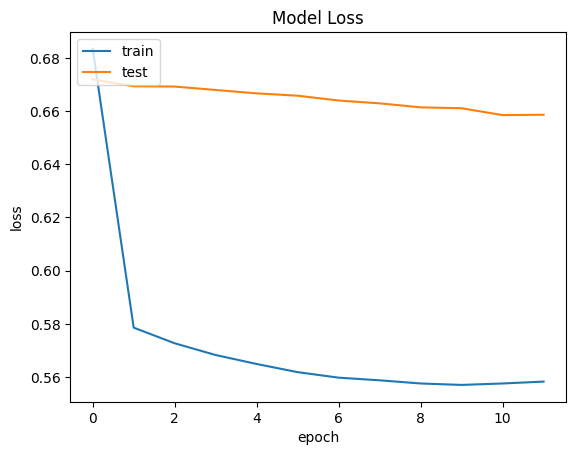

In [ ]:
plt.plot(hitsory.history['loss'])
plt.plot(hitsory.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

In [ ]:
# Evaluasi train
train_loss, train_rmse, train_mse = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_rmse, test_mse = model.evaluate(x_test, y_test, verbose=0)
print(f"Train Loss: {train_loss:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Train MSE: {train_mse:.4f}")
print('')
print(f"Test Loss: {test_loss:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MSE: {test_mse:.4f}")

Train Loss: 0.5815
Train RMSE: 0.2059
Train MSE: 0.0424

Test Loss: 0.6593
Test RMSE: 0.2836
Test MSE: 0.0804




Pendekatan ini menggunakan evaluasi matriks Mean Squared Error dan Root Mean Squared Error.

- **Mean Squared Error (MSE)**
    Digunakan untuk menghitung nilai selisih antara rating prediksi dan rating aktual. Metirk ini memberikan gambaran intuisif tentang kesalahan rata-rata pada saat prediksi.

    ![MAE](https://latex.codecogs.com/png.image?\dpi{150}&space;\text{MAE}=\frac{1}{n}\sum_{i=1}^{n}\left|\hat{y}_i-y_i\right|)


- **Root Mean Squared Error (RMSE)**
    Digunakan untuk mengukur rata-rata kesalahan kuadrat dari prediksi terhadap nilai aktual. Semakin kecil nilai RMSE, maka semakin baik performanya.

    ![RMSE](https://latex.codecogs.com/png.image?\dpi{150}&space;\text{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2})


**Hasil**

*Tabel 2, Evaluasi Matriks Content Filtering*

|        Data       |   MAE   |  RMSE   |
|:-----------------:|:-------:|:-------:|
| **Latih**         | 0.0424  | 0.2059  |
| **Uji**           | 0.0804  | 0.2836  |

Artinya, model lebih baik melakukan pelatihan dibandingkan dengan pengujian. Meskipun demikian, nilainya data latih dan data uji tidak berbeda jauh yang menandakan model tidak terjadi overfitting dan menggeneralisasi dengan baik.

Evaluasi pada kedua model menandakan bahwa model dapat berjalan dengan baik, juga memberikan rekomendasi yang berkualitas dan kinerjanya terukur.

## Kesimpulan

Proyek ini mampu memberikan sistem rekomendasi dengan pendekatan content-based filtering dan collaborative filtering untuk memberikan pengguna pengalaman dalam menemukan buku yang sesuai dengan preferensi mereka. Sehingga kesimpulan yang didapatkan pada proyek ini, yaitu:

1. Sistem rekomendasi berhasil dibangun menggunakan dua pendekatan, yaitu:
    - Content-Based Filtering, menggunakan TF-IDF dalam merepresentasikan vektor dan cosine similarity untuk mengukur kemiripan antar buku berdasarkan informasi kontennya.
    - Collaborative Filtering, menggunakan pendekatan neural network, mampu memprediksi interaksi pengguna buku berdasarkan informasi pengguna dan menangkap pola yang rumit.
2. Hasil evaluasi pada kedua model, baik content-based dengan F1 Score dan collaborative filtering dengan RMSE dan MSE memberikan performa yang baik sehingga kedua model mempu menangani pola interaksi pengguna yang kompleks.
3. Keterikatan model dengan business understanding. Baik problem statement dan tujuan bisnis mampu dicapai dan solusi yang diajukan berdampak kepada pengembangan sistem.
4. Sistem rekomendasi ini dapat meningkatkan kepuasan pengguna dengan menyediakan kepuasn terhadap pengguna dengan menyediakan rekomendasi buku yang sesuai minat sehingga mendorong eksplorasi terhadap koleksi buku secara luas.
